In [10]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.17.1
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---


In [11]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import torch
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from torch import nn
from a03_helper import (
    nextplot,
    tsne_vocab,
    tsne_thought,
    DEVICE,
    reviews_load_embeddings,
)
from a03_functions import SimpleLSTM, ReviewsDataset, ReviewsDataModule, LitSimpleLSTM
import matplotlib.pyplot as plt


## Task 5: Pre-trained Embeddings & Visualization


### Task 5b


In [13]:
# Load Glove embeddings into a plain embedding layer.
dataset = ReviewsDataset(use_vocab=True)
vocab = dataset.vocab
glove_embeddings = nn.Embedding(len(vocab), 100, device=DEVICE)
reviews_load_embeddings(glove_embeddings, vocab.get_stoi())


Initializing embedding layer with pretrained word embeddings...
Initialized 29841/32363 word embeddings


In [14]:
# Print one embedding
glove_embeddings(torch.tensor(vocab["movie"], device=DEVICE))


tensor([ 0.3825,  0.1482,  0.6060, -0.5153,  0.4399,  0.0611, -0.6272, -0.0254,
         0.1643, -0.2210,  0.1442, -0.3721, -0.2168, -0.0890,  0.0979,  0.6561,
         0.6446,  0.4770,  0.8385,  1.6486,  0.8892, -0.1181, -0.0125, -0.5208,
         0.7785,  0.4872, -0.0150, -0.1413, -0.3475, -0.2959,  0.1028,  0.5719,
        -0.0456,  0.0264,  0.5382,  0.3226,  0.4079, -0.0436, -0.1460, -0.4835,
         0.3204,  0.5509, -0.7626,  0.4327,  0.6175, -0.3650, -0.6060, -0.7962,
         0.3929, -0.2367, -0.3472, -0.6120,  0.5475,  0.9481,  0.2094, -2.7771,
        -0.6022,  0.8495,  1.2549,  0.0179, -0.0419,  2.1147, -0.0266, -0.2810,
         0.6812, -0.1417,  0.9925,  0.4988, -0.6754,  0.6417,  0.4230, -0.2791,
         0.0634,  0.6891, -0.3618,  0.0537, -0.1681,  0.1942, -0.4707, -0.1480,
        -0.5899, -0.2797,  0.1679,  0.1057, -1.7601,  0.0088, -0.8333, -0.5836,
        -0.3708, -0.5659,  0.2070,  0.0713,  0.0556, -0.2976, -0.0727, -0.2560,
         0.4269,  0.0589,  0.0911,  0.47

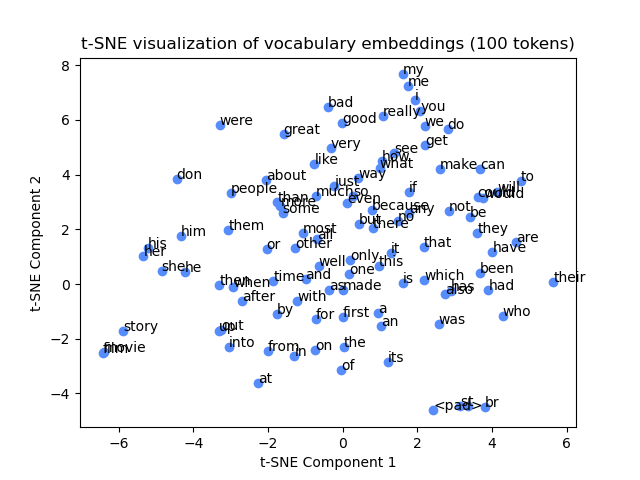

In [20]:
# Plot embeddings of first 100 words using t-SNE
nextplot()
_ = tsne_vocab(glove_embeddings, torch.arange(100), vocab)
plt.gcf().savefig("task5b_glove_tsne_first100_labeled.png", dpi=300, bbox_inches="tight")


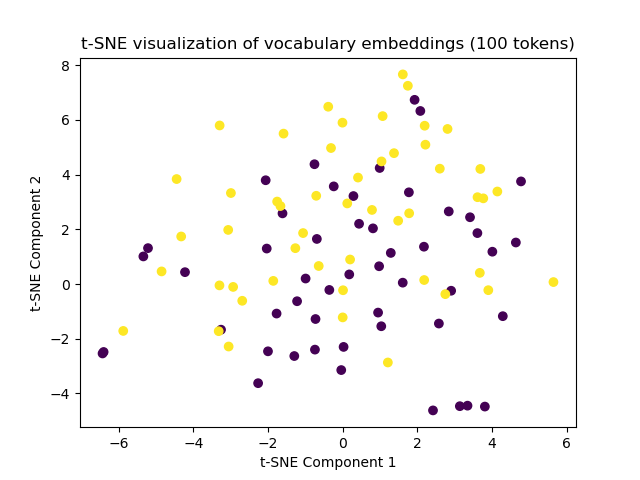

In [21]:
# You can also specify colors and/or drop the item labels
nextplot()
_ = tsne_vocab(glove_embeddings, torch.arange(100), colors=[0] * 50 + [1] * 50)
plt.gcf().savefig("task5b_glove_tsne_first100_colored.png", dpi=300, bbox_inches="tight")


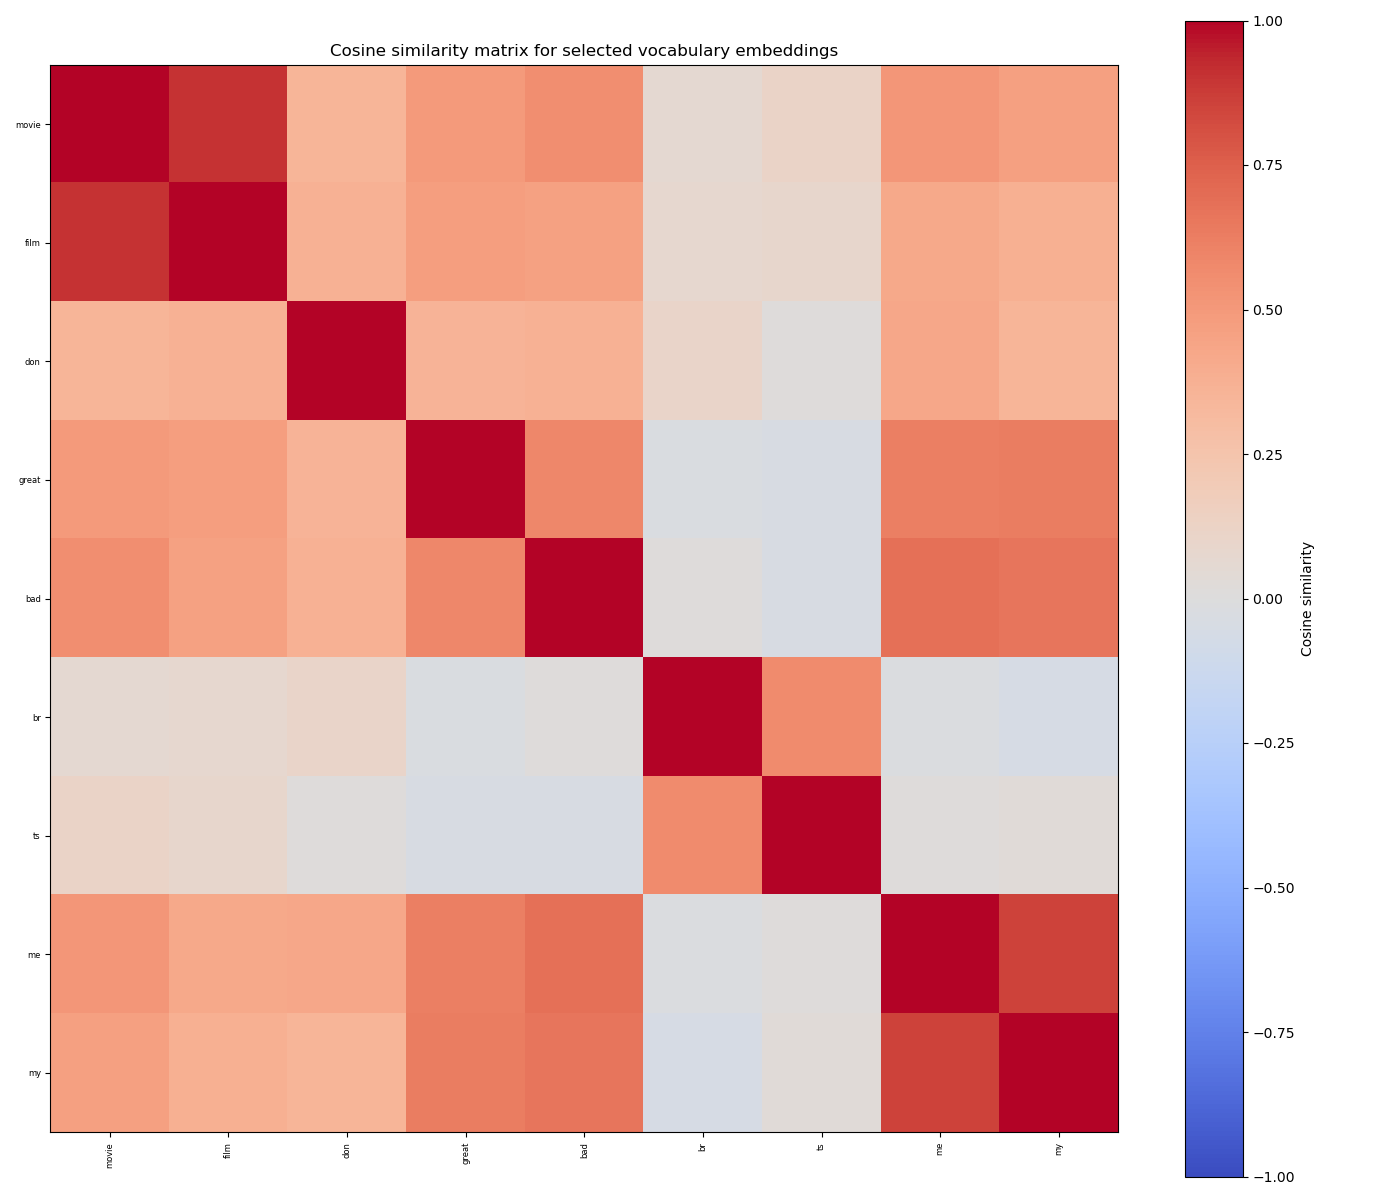

In [22]:
# TODO: Your code here (Task 5b: cosine-similarity visualization)
# Explore selected GloVe embeddings with cosine similarities.
import torch.nn.functional as F

selected_words = [
    "movie", "film",
    "don", "great", "bad",
    "br", "ts",
    "me", "my",
]
selected_words = [word for word in selected_words if word in vocab.get_stoi()]
token_ids = torch.tensor([vocab[word] for word in selected_words], device=DEVICE)

embeddings = glove_embeddings.weight.data[token_ids]
embeddings = F.normalize(embeddings, dim=1)
similarities = embeddings @ embeddings.T
token_labels = [vocab.get_itos()[idx] for idx in token_ids.cpu().tolist()]

plt.figure(figsize=(14, 12))
plt.imshow(similarities.cpu(), cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(token_labels)), token_labels, rotation=90, fontsize=6)
plt.yticks(range(len(token_labels)), token_labels, fontsize=6)
plt.title("Cosine similarity matrix for selected vocabulary embeddings")
plt.tight_layout()
plt.savefig("task5b_glove_cosine_selected_words.png", dpi=300, bbox_inches="tight")
plt.show()


### Task 5c


In [23]:
# hyperparameter settings for rest of task 5
vocab_size = len(dataset.vocab)
embedding_dim = 100
hidden_dim = 100
num_layers = 2
n_epochs = 10
cell_dropout = 0.0


In [24]:
# TODO: Your code here (Task 5c: train plain LSTM)
model = LitSimpleLSTM(vocab_size, embedding_dim, hidden_dim, num_layers, cell_dropout)
dataset = ReviewsDataset(use_vocab=True)
dm = ReviewsDataModule(dataset)

# Train a plain model so that it reaches a train accuracy of >0.9.
logger = TensorBoardLogger("logs", name="task5c_plain_lstm")
trainer = Trainer(
    logger=logger,
    max_epochs=n_epochs,
    check_val_every_n_epoch=1,
    gradient_clip_val=3,
)

trainer.fit(model, datamodule=dm)
print("Task 5c train/validation metrics:")
print(trainer.callback_metrics)
print("Task 5c test metrics:")
print(trainer.test(model, datamodule=dm))


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | SimpleLSTM | 3.4 M  | train | 0    
-----------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.592    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

`Trainer.fit` stopped: `max_epochs=10` reached.


Task 5c train/validation metrics:
{'train_loss': tensor(0.2271), 'train_loss_step': tensor(0.2289), 'val_loss': tensor(0.9028), 'val_acc': tensor(0.6750), 'train_loss_epoch': tensor(0.2271), 'train_acc': tensor(0.9131)}
Task 5c test metrics:


C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6524999737739563
        test_loss           0.9546206593513489
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'test_loss': 0.9546206593513489, 'test_acc': 0.6524999737739563}]


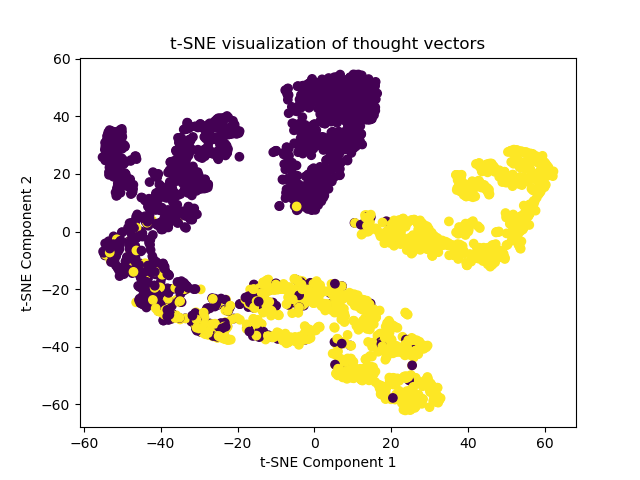

In [25]:
# Plot t-SNE embeddings of the thought vectors for training data
# point color = label
dm.setup("fit")
train_loader = dm.train_dataloader()
nextplot()
_ = tsne_thought(model, train_loader, DEVICE)
plt.gcf().savefig("task5c_plain_train_thought_tsne.png", dpi=300, bbox_inches="tight")


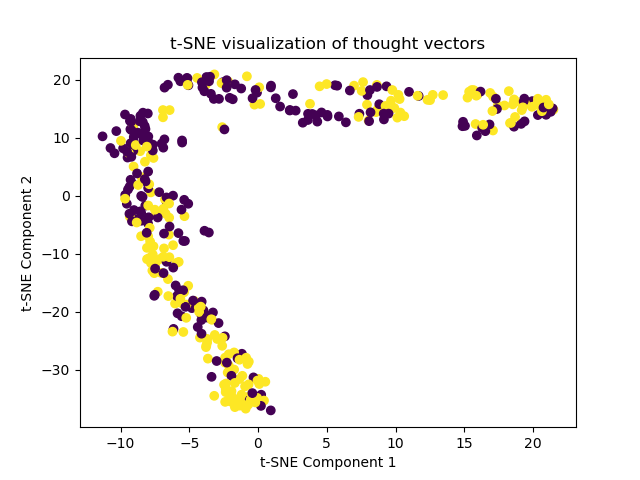

In [26]:
# Plot t-SNE embeddings of of the thought vectors for validation data
dm.setup("fit")
val_loader = dm.val_dataloader()
nextplot()
_ = tsne_thought(model, val_loader, DEVICE)
plt.gcf().savefig("task5c_plain_val_thought_tsne.png", dpi=300, bbox_inches="tight")


### Task 5d


Initializing embedding layer with pretrained word embeddings...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | SimpleLSTM | 3.4 M  | train | 0    
-----------------------------------------------------
3.4 M     Trainable params
0         Non-trainable params
3.4 M     Total params
13.592    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Initialized 29841/32363 word embeddings


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


...

`Trainer.fit` stopped: `max_epochs=10` reached.


Task 5d train/validation metrics:
{'train_loss': tensor(0.0026), 'train_loss_step': tensor(0.0004), 'val_loss': tensor(0.8179), 'val_acc': tensor(0.8675), 'train_loss_epoch': tensor(0.0026), 'train_acc': tensor(0.9997)}
Task 5d test metrics:


C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.8774999976158142
        test_loss            0.735546886920929
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'test_loss': 0.735546886920929, 'test_acc': 0.8774999976158142}]


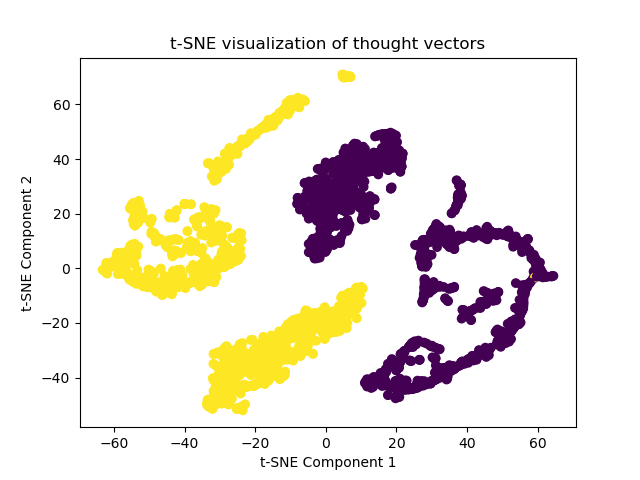

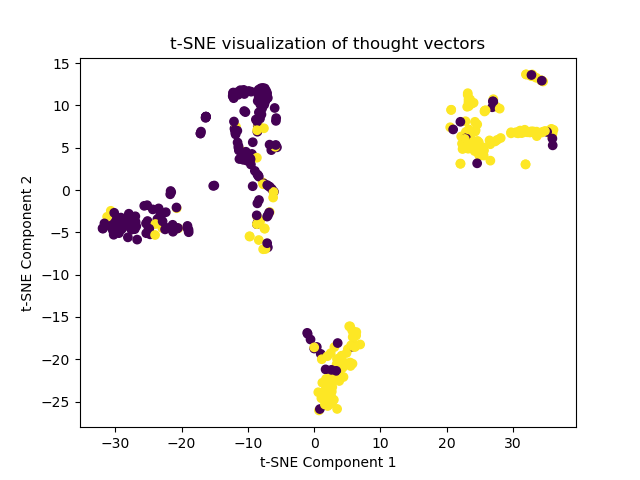

In [27]:
# TODO: Your code here (Task 5d: GloVe initialization with finetuning)
# Initialize the model with *p*re-trained embeddings with *f*inetuning, then
# train.
model_pf = LitSimpleLSTM(
    vocab_size, embedding_dim, hidden_dim, num_layers, cell_dropout
)
reviews_load_embeddings(model_pf.model.embedding, vocab.get_stoi())

logger_pf = TensorBoardLogger("logs", name="task5d_glove_finetune")
trainer_pf = Trainer(
    max_epochs=n_epochs,
    gradient_clip_val=3,
    check_val_every_n_epoch=1,
    logger=logger_pf,
)

trainer_pf.fit(model_pf, datamodule=dm)
print("Task 5d train/validation metrics:")
print(trainer_pf.callback_metrics)
print("Task 5d test metrics:")
print(trainer_pf.test(model_pf, datamodule=dm))

# Plot t-SNE embeddings of the thought vectors for training data.
dm.setup("fit")
train_loader = dm.train_dataloader()
nextplot()
_ = tsne_thought(model_pf, train_loader, DEVICE)
plt.gcf().savefig("task5d_glove_finetune_train_thought_tsne.png", dpi=300, bbox_inches="tight")

# Plot t-SNE embeddings of the thought vectors for validation data.
val_loader = dm.val_dataloader()
nextplot()
_ = tsne_thought(model_pf, val_loader, DEVICE)
plt.gcf().savefig("task5d_glove_finetune_val_thought_tsne.png", dpi=300, bbox_inches="tight")


### Task 5e


Initializing embedding layer with pretrained word embeddings...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type       | Params | Mode  | FLOPs
-----------------------------------------------------
0 | model | SimpleLSTM | 3.4 M  | train | 0    
-----------------------------------------------------
161 K     Trainable params
3.2 M     Non-trainable params
3.4 M     Total params
13.592    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Initialized 29841/32363 word embeddings


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


...

`Trainer.fit` stopped: `max_epochs=10` reached.


Task 5e train/validation metrics:
{'train_loss': tensor(0.6188), 'train_loss_step': tensor(0.5998), 'val_loss': tensor(0.7403), 'val_acc': tensor(0.5600), 'train_loss_epoch': tensor(0.6188), 'train_acc': tensor(0.6341)}
Task 5e test metrics:


C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.6025000214576721
        test_loss           0.7146604657173157
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
[{'test_loss': 0.7146604657173157, 'test_acc': 0.6025000214576721}]


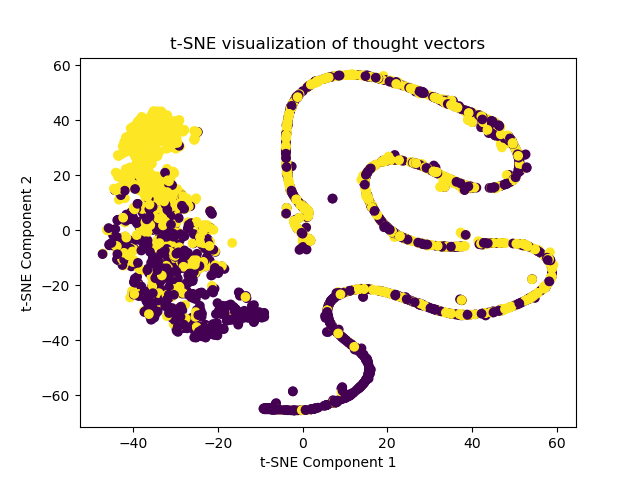

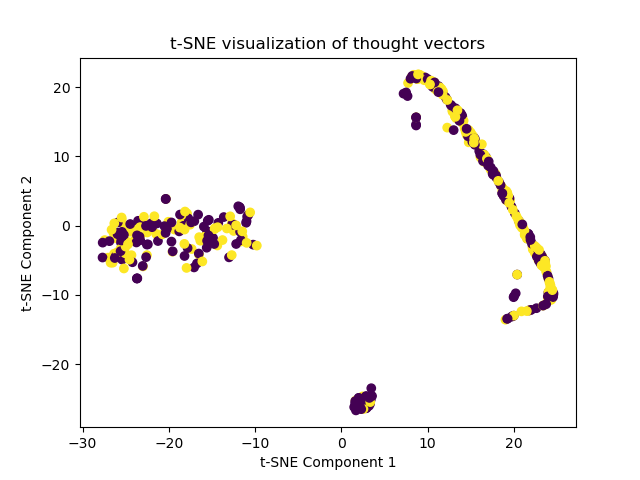

In [28]:
# TODO: Your code here (Task 5e: GloVe initialization without finetuning)
# Initialize the model with *p*re-trained embeddings without finetuning, then
# train.
model_p = LitSimpleLSTM(vocab_size, embedding_dim, hidden_dim, num_layers, cell_dropout)
reviews_load_embeddings(model_p.model.embedding, vocab.get_stoi())
model_p.model.embedding.weight.requires_grad = False

logger_p = TensorBoardLogger("logs", name="task5e_glove_frozen")
trainer_p = Trainer(
    max_epochs=n_epochs,
    gradient_clip_val=3,
    check_val_every_n_epoch=1,
    logger=logger_p,
)

trainer_p.fit(model_p, datamodule=dm)
print("Task 5e train/validation metrics:")
print(trainer_p.callback_metrics)
print("Task 5e test metrics:")
print(trainer_p.test(model_p, datamodule=dm))

# Plot t-SNE embeddings of the thought vectors for training data.
dm.setup("fit")
train_loader = dm.train_dataloader()
nextplot()
_ = tsne_thought(model_p, train_loader, DEVICE)
plt.gcf().savefig("task5e_glove_frozen_train_thought_tsne.png", dpi=300, bbox_inches="tight")

# Plot t-SNE embeddings of the thought vectors for validation data.
val_loader = dm.val_dataloader()
nextplot()
_ = tsne_thought(model_p, val_loader, DEVICE)
plt.gcf().savefig("task5e_glove_frozen_val_thought_tsne.png", dpi=300, bbox_inches="tight")
